# Distribution Analysis
วิเคราะห์การกระจายตัวของตัวแปรที่สำคัญต่อการ churn โดยอ้างอิงจากผล feature importance ของโมเดล

## Feature Priority Overview
ส่วนนี้จะดึงผลจาก `feature_importance.csv` เพื่อจัดลำดับว่าควรวิเคราะห์ distribution ของ feature ไหนก่อน

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from IPython.display import display

palette_level = {
    'Strong': '#c8553d',
    'Moderate': '#4c956c',
    'Weak': '#577590',
    'None': '#b7b7a4'
}
churn_palette = {0: '#4c78a8', 1: '#e45756'}
level_order = ['Strong', 'Moderate', 'Weak', 'None']

sns.set_theme(style="whitegrid")

df = pd.read_csv('../../../Data/processed/cleaned_customer_data.csv')
df_importance = pd.read_csv('../../../Data/processed/feature_importance.csv', keep_default_na=False)
df_importance['importance_level'] = pd.Categorical(
    df_importance['importance_level'],
    categories=level_order,
    ordered=True
)
df_importance = df_importance.sort_values('importance', ascending=False).reset_index(drop=True)

def features_by_level(level):
    return df_importance.loc[
        df_importance['importance_level'] == level,
        'feature'
    ].tolist()

def plot_feature_distribution(feature, ax):
    feature_data = df[feature].dropna()
    importance_value = df_importance.loc[
        df_importance['feature'] == feature,
        'importance'
    ].iloc[0]
    importance_level = df_importance.loc[
        df_importance['feature'] == feature,
        'importance_level'
    ].iloc[0]

    if feature_data.nunique() <= 12:
        sns.histplot(
            data=df,
            x=feature,
            hue='Churned',
            multiple='layer',
            stat='density',
            common_norm=False,
            alpha=0.45,
            bins=min(feature_data.nunique(), 12),
            ax=ax,
            palette=churn_palette
        )
    else:
        sns.kdeplot(
            data=df,
            x=feature,
            hue='Churned',
            fill=True,
            common_norm=False,
            alpha=0.35,
            linewidth=1.5,
            ax=ax,
            palette=churn_palette
        )

    ax.set_title(
        f'{feature}\nimportance = {importance_value:.4f} ({importance_level})',
        fontsize=12,
        weight='bold'
    )
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')

def plot_features_by_level(level, ncols=2):
    features = features_by_level(level)
    if not features:
        print(f'No features found for level: {level}')
        return

    nrows = math.ceil(len(features) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4.5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, feature in zip(axes, features):
        plot_feature_distribution(feature, ax)

    for ax in axes[len(features):]:
        ax.remove()

    fig.suptitle(f'{level} Impact Features', fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## Top Features From Model
ตารางและกราฟนี้ช่วยสรุปว่า feature ใดมีอิทธิพลสูงสุด ก่อนลงไปดู distribution แยกตาม churn

,feature,importance,importance_level
0,Lifetime_Value,0.1290,Strong
1,Customer_Service_Calls,0.1279,Strong
2,Cart_Abandonment_Rate,0.0991,Strong
3,Discount_Usage_Rate,0.0715,Strong
4,Age,0.0685,Strong
5,Days_Since_Last_Purchase,0.0609,Strong
6,Total_Purchases,0.0556,Moderate
7,Email_Open_Rate,0.0473,Moderate
8,Average_Order_Value,0.0473,Moderate
9,Session_Duration_Avg,0.0408,Moderate


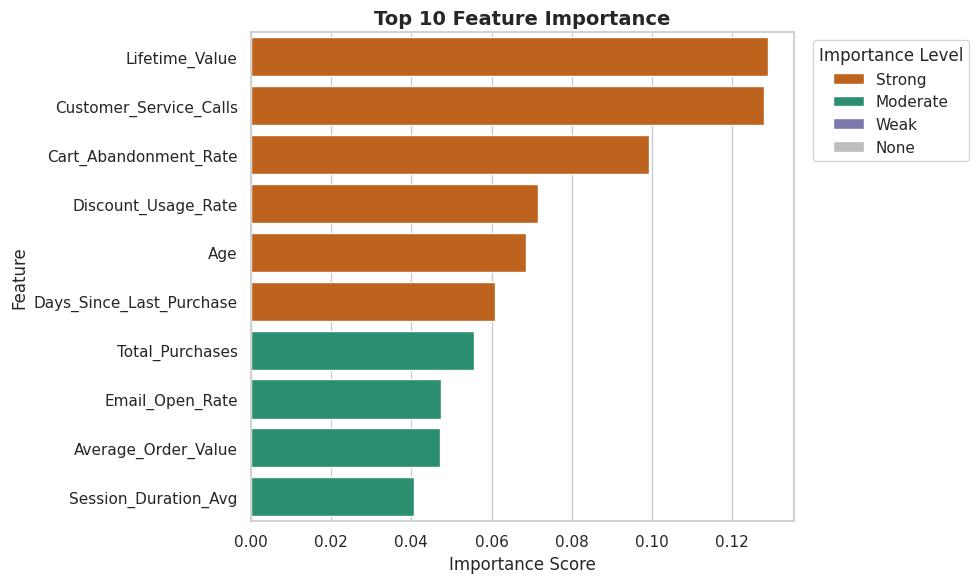

Top 10 features for distribution analysis:
1. Lifetime_Value
2. Customer_Service_Calls
3. Cart_Abandonment_Rate
4. Discount_Usage_Rate
5. Age
6. Days_Since_Last_Purchase
7. Total_Purchases
8. Email_Open_Rate
9. Average_Order_Value
10. Session_Duration_Avg


In [7]:
top10_importance = df_importance.head(10).copy()
top10_features = top10_importance['feature'].tolist()

display(
    top10_importance.assign(
        importance=top10_importance['importance'].round(4)
    )
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top10_importance,
    x='importance',
    y='feature',
    hue='importance_level',
    dodge=False,
    palette={'Strong': '#d95f02', 'Moderate': '#1b9e77', 'Weak': '#7570b3', 'None': '#bdbdbd'}
)
plt.title('Top 10 Feature Importance', fontsize=14, weight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.legend(title='Importance Level', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('Top 10 features for distribution analysis:')
for index, feature in enumerate(top10_features, start=1):
    print(f'{index}. {feature}')

## Importance Level Summary
สรุปจำนวน feature ในแต่ละระดับผลกระทบ และใช้เป็นแผนสำหรับการวิเคราะห์ distribution ต่อไป

,importance_level,feature_count,avg_importance,max_importance
0,Strong,6,0.0928,0.1290
1,Moderate,5,0.0463,0.0556
2,Weak,5,0.0282,0.0334
3,None,0,NaN,NaN


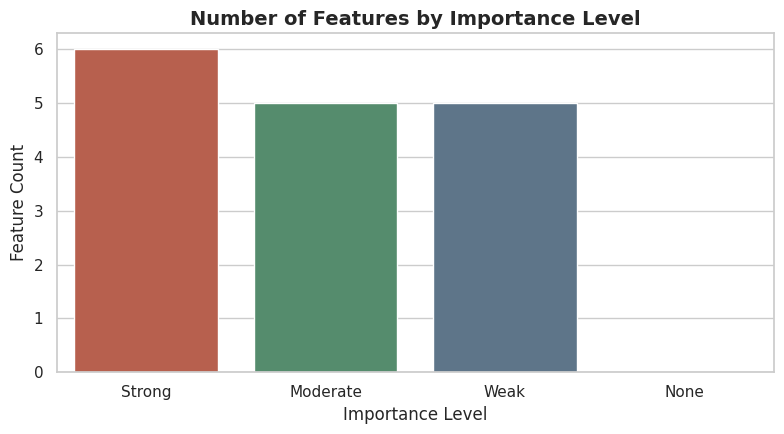

Strong: Lifetime_Value, Customer_Service_Calls, Cart_Abandonment_Rate, Discount_Usage_Rate, Age, Days_Since_Last_Purchase
Moderate: Total_Purchases, Email_Open_Rate, Average_Order_Value, Session_Duration_Avg, Pages_Per_Session
Weak: Returns_Rate, Mobile_App_Usage, Credit_Balance, Social_Media_Engagement_Score, Login_Frequency
None: 


In [8]:
summary_by_level = (
    df_importance.groupby('importance_level', observed=False)
    .agg(
        feature_count=('feature', 'count'),
        avg_importance=('importance', 'mean'),
        max_importance=('importance', 'max')
    )
    .reset_index()
)

summary_display = summary_by_level.assign(
    avg_importance=summary_by_level['avg_importance'].round(4),
    max_importance=summary_by_level['max_importance'].round(4)
)
display(summary_display)

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=summary_by_level,
    x='importance_level',
    y='feature_count',
    order=level_order,
    hue='importance_level',
    dodge=False,
    palette=palette_level
)
plt.title('Number of Features by Importance Level', fontsize=14, weight='bold')
plt.xlabel('Importance Level')
plt.ylabel('Feature Count')
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

for level in level_order:
    features = features_by_level(level)
    print(f'{level}: {", ".join(features)}')

## Strong Impact Features
กลุ่มนี้คือปัจจัยหลักที่มีอิทธิพลต่อ churn สูงสุด และควรเป็นแกนของ insight เชิงธุรกิจ

Features ในกลุ่มนี้ควรถูกอ่านเป็นสัญญาณหลักของ churn เพราะทั้ง importance score สูงและรูป distribution มักแยก churn กับ non-churn ได้ชัด

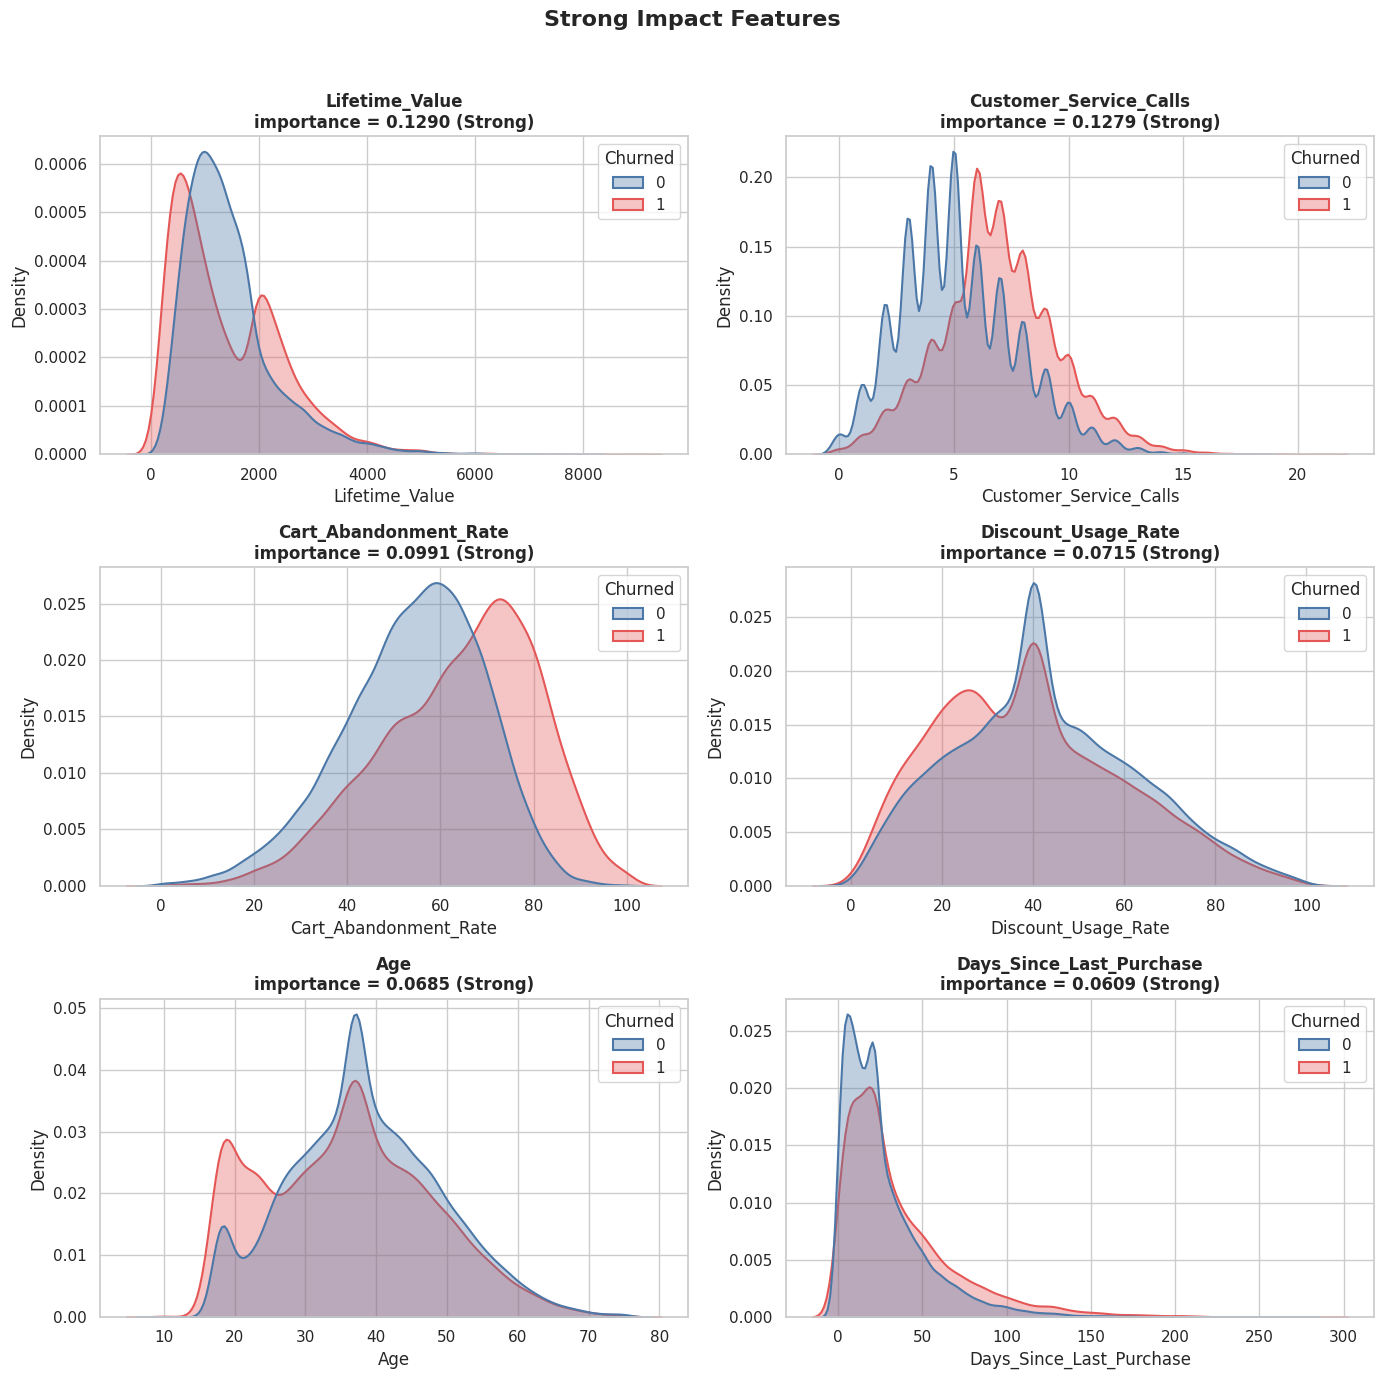

In [9]:
plot_features_by_level('Strong', ncols=2)

## Moderate Impact Features
กลุ่มนี้ยังมีผลต่อ churn ชัดเจน แต่เป็นปัจจัยรองจากกลุ่ม Strong และเหมาะกับการใช้สนับสนุน insight หลัก

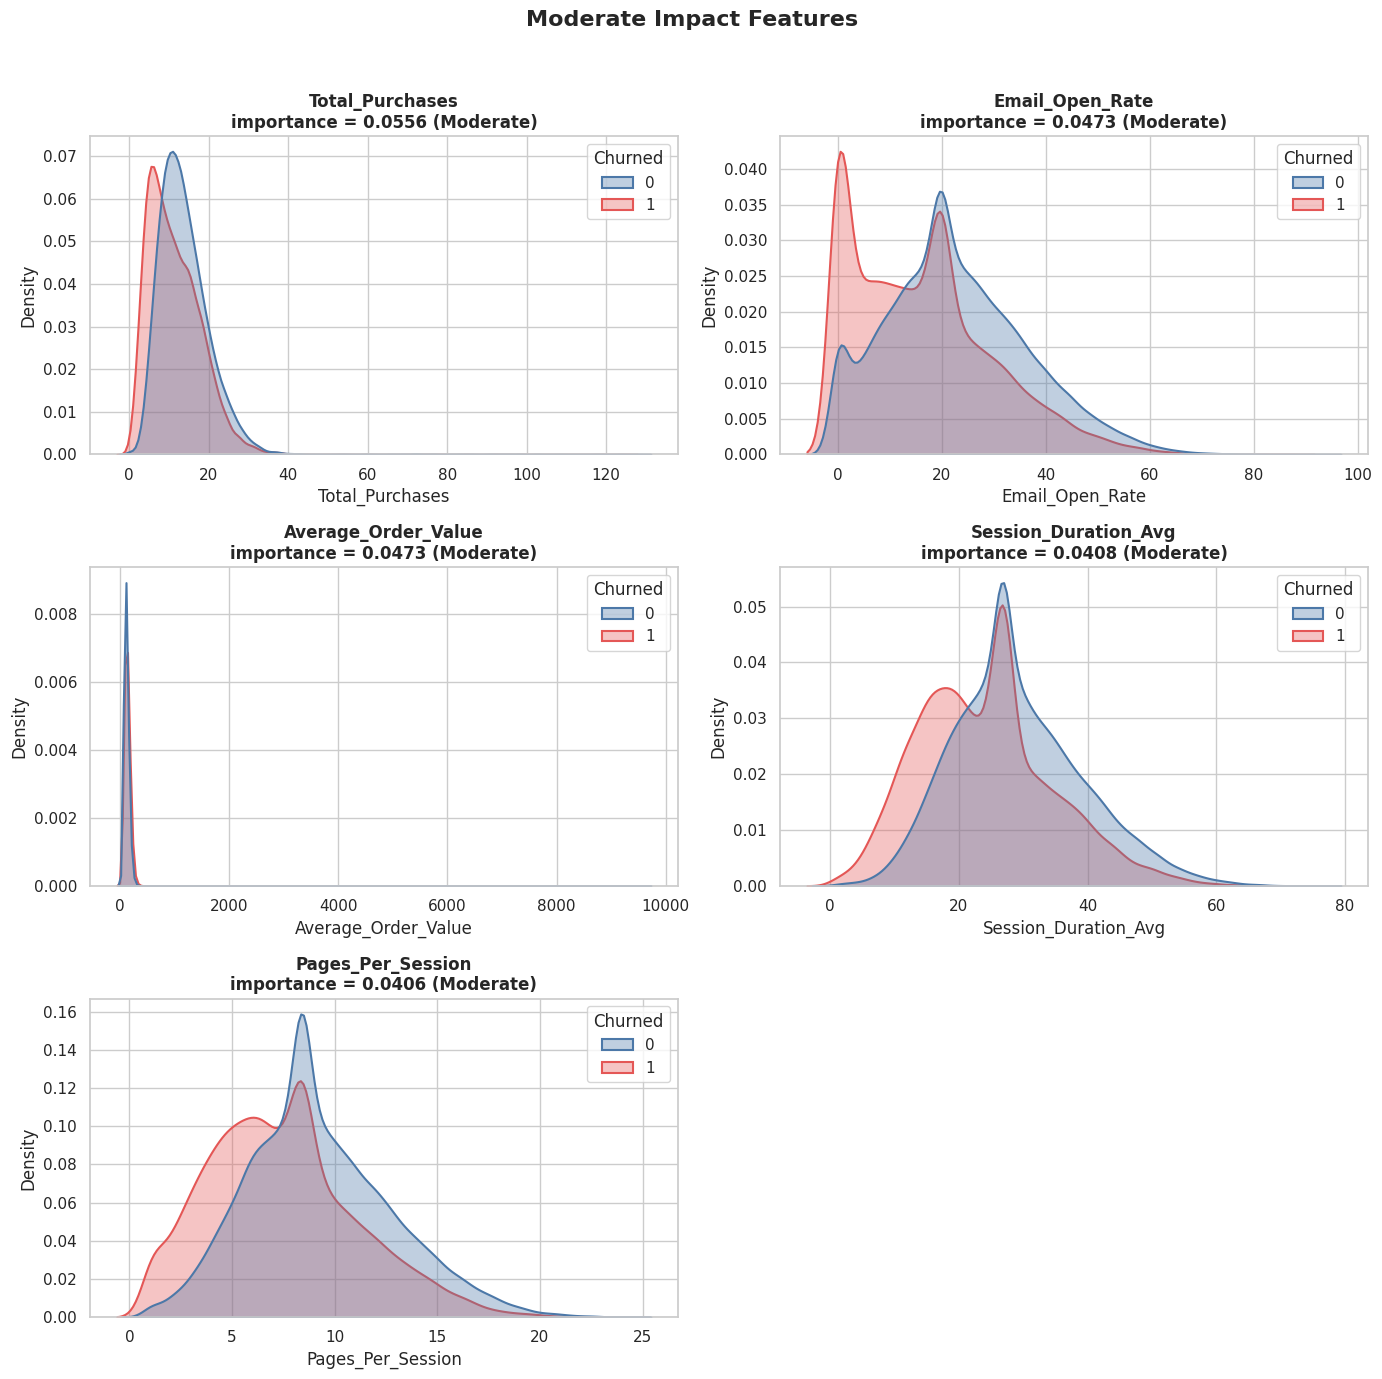

In [10]:
plot_features_by_level('Moderate', ncols=2)

Moderate features มักสะท้อนพฤติกรรมลูกค้าที่สัมพันธ์กับ churn แต่ไม่แรงพอจะใช้เดี่ยว ๆ จึงเหมาะกับการอธิบายร่วมกับ Strong features

## Weak Impact Features
กลุ่มนี้มีผลต่อ churn ในระดับอ่อน เหมาะกับการใช้เป็นตัวเสริมบริบท ไม่ใช่ตัวแปรหลักในการตัดสินใจ

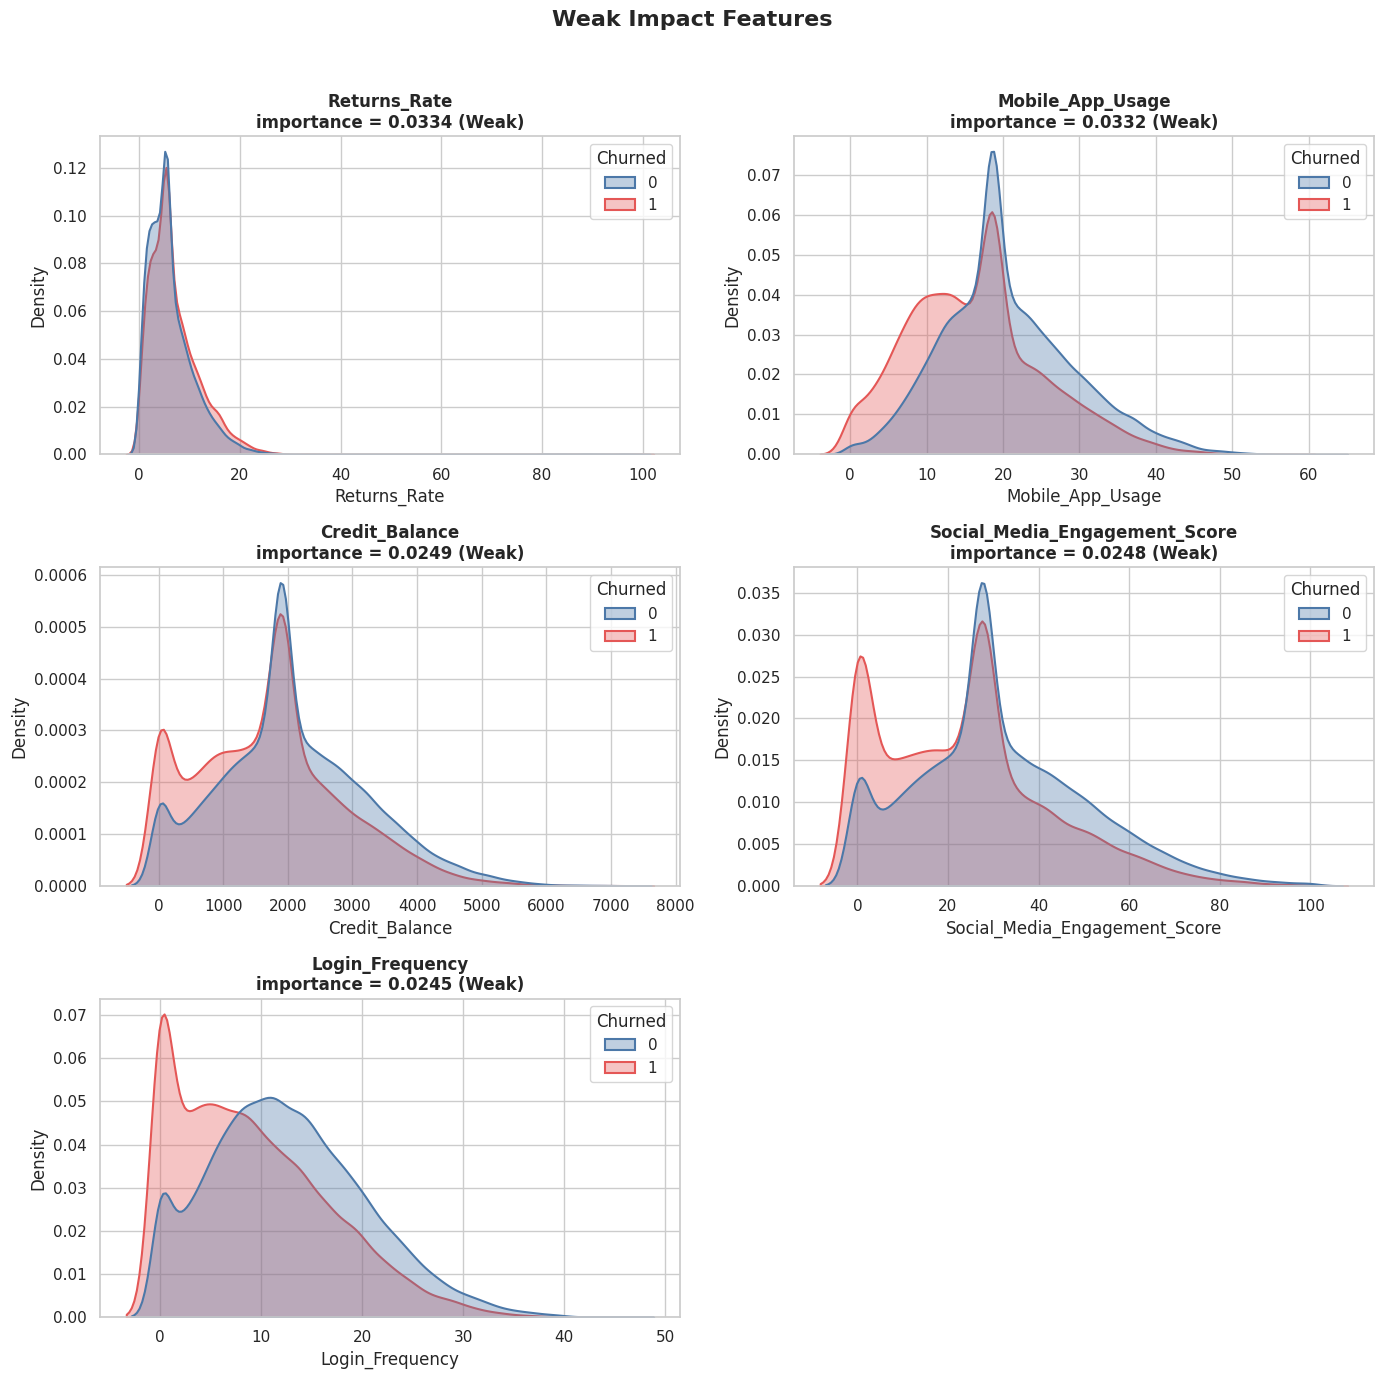

In [11]:
plot_features_by_level('Weak', ncols=2)

## No Clear Impact Features
กลุ่มนี้มี importance ต่ำมากหรือแทบไม่มีผล จึงควรใช้เพื่อยืนยันว่า feature ใดไม่จำเป็นต้องเป็น focus ในการเล่าเรื่อง

In [13]:
plot_features_by_level('None', ncols=2)

No features found for level: None
